<a href="https://colab.research.google.com/github/carloscifuentesingsoft1560-cyber/Redes_neuronales/blob/main/main_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!wget --no-check-certificate https://storage.googleapis.com/platzi-tf2/sign-language-img.zip \
    -O /tmp/sign-language-img.zip

--2026-05-14 12:47:51--  https://storage.googleapis.com/platzi-tf2/sign-language-img.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 64.233.181.207, 173.194.206.207, 173.194.193.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|64.233.181.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 24265584 (23M) [application/zip]
Saving to: ‘/tmp/sign-language-img.zip’

/tmp/sign-language- 100%[===================>]  23.14M  --.-KB/s    in 0.1s    

2026-05-14 12:47:51 (213 MB/s) - ‘/tmp/sign-language-img.zip’ saved [24265584/24265584]



In [2]:
#descomprimila

import os
import zipfile

local_zip = '/tmp/sign-language-img.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/tmp/sign-language-img')
zip_ref.close()

In [3]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import string
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [4]:
train_dir = '/tmp/sign-language-img/Train'
test_dir = '/tmp/sign-language-img/Test'

In [5]:
train_datagen = ImageDataGenerator(rescale = 1/255)
test_datagen = ImageDataGenerator(rescale = 1/255, validation_split = 0.2)

In [6]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size = (28,28),
    batch_size = 128,
    class_mode = 'categorical',
    color_mode = 'grayscale',
    subset = 'training'
)
validation_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size = (28,28),
    batch_size = 128,
    class_mode = 'categorical',
    color_mode = 'grayscale',
    subset = 'validation'
)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size = (28,28),
    batch_size = 128,
    class_mode = 'categorical',
    color_mode = 'grayscale',

)

Found 27455 images belonging to 24 classes.
Found 1425 images belonging to 24 classes.
Found 7172 images belonging to 24 classes.


In [7]:
clases = [char for char in string.ascii_uppercase if char !="J" if char !="Z"]

In [8]:
clases

['A',
 'B',
 'C',
 'D',
 'E',
 'F',
 'G',
 'H',
 'I',
 'K',
 'L',
 'M',
 'N',
 'O',
 'P',
 'Q',
 'R',
 'S',
 'T',
 'U',
 'V',
 'W',
 'X',
 'Y']

In [9]:
def plotImages(image_arr):
  fig, axes = plt.subplots(1, 5, figsize=(10,10))
  axes = axes.flatten()
  for img, ax in zip(image_arr, axes):
    ax.imshow(img[:,:,0])
    ax.axis('off')
  plt.tight_layout()
  plt.show()


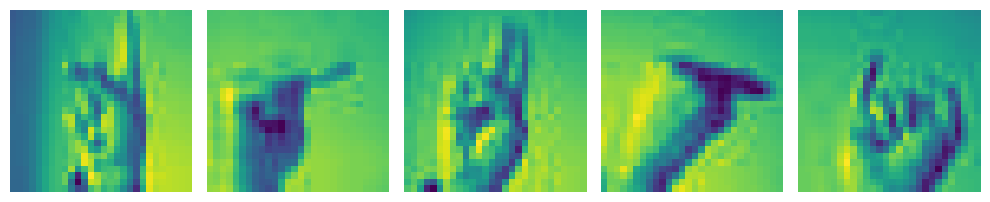

In [10]:
sample_trainig_images, _ = next(train_generator)
plotImages(sample_trainig_images[:5])

In [ ]:
model_base = tf.keras.models.Sequential([
                                        tf.keras.layers.Flatten(input_shape= (28,28,1)),
                                        tf.keras.layers.Dense(256, activation="relu"),
                                        tf.keras.layers.Dense(128, activation="relu"),
                                        tf.keras.layers.Dense(len(clases), activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model_base.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 236,952 (925.59 KB)

 Trainable params: 236,952 (925.59 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_base.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])


history = model_base.fit(
    train_generator,
    epochs = 20,
    validation_data = validation_generator
)

Epoch 1/20
 43/215 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.0800 - loss: 3.1921

KeyboardInterrupt: 

In [ ]:
results = model_base.evaluate(test_generator)

57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.7331 - loss: 1.3638


In [11]:
def visualizacion_resultados(history):
  epochs =[i for i in range(20)]
  fig, ax = plt.subplots(1,2)
  train_acc = history.history["accuracy"]
  train_loss = history.history["loss"]
  val_acc = history.history["val_accuracy"]
  val_loss = history.history["val_loss"]
  fig.set_size_inches(16,9)

  ax[0].plot(epochs, train_acc, "go-", label="Entrenamiento Accuracy")
  ax[0].plot(epochs, val_acc, "ro-", label="Validacion  Accuracy")
  ax[0].set_title("Entrenamiento vs Validacion Accuracy")
  ax[0].legend()
  ax[0].set_xlabel("Epochs")
  ax[0].set_ylabel("Accuracy")

  ax[1].plot(epochs, train_loss, "go-", label="Entrenamiento Loss")
  ax[1].plot(epochs, val_loss, "ro-", label="Validacion  Loss")
  ax[1].set_title("Entrenamiento vs Validacion Loss")
  ax[1].legend()
  ax[1].set_xlabel("Epochs")
  ax[1].set_ylabel("Loss")

  plt.show()


In [ ]:
visualizacion_resultados(history)

NameError: name 'history' is not defined

In [16]:
from tensorflow.keras import regularizers

In [17]:
model_optimizer = tf.keras.models.Sequential([
                                        tf.keras.layers.Flatten(input_shape= (28,28,1)),
                                        tf.keras.layers.Dense(256,kernel_regularizer= regularizers.l2(1e-5), activation="relu"),
                                        tf.keras.layers.Dropout(0.2),
                                        tf.keras.layers.Dense(128, kernel_regularizer= regularizers.l2(1e-5), activation="relu"),
                                        tf.keras.layers.Dropout(0.2),
                                        tf.keras.layers.Dense(len(clases), activation="softmax")
])

In [ ]:
model_optimizer.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 236,952 (925.59 KB)

 Trainable params: 236,952 (925.59 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_optimizer.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

history_optimizer = model_optimizer.fit(
    train_generator,
    epochs = 20,
    validation_data = validation_generator
)

Epoch 1/20
100/215 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.0738 - loss: 3.1381

KeyboardInterrupt: 

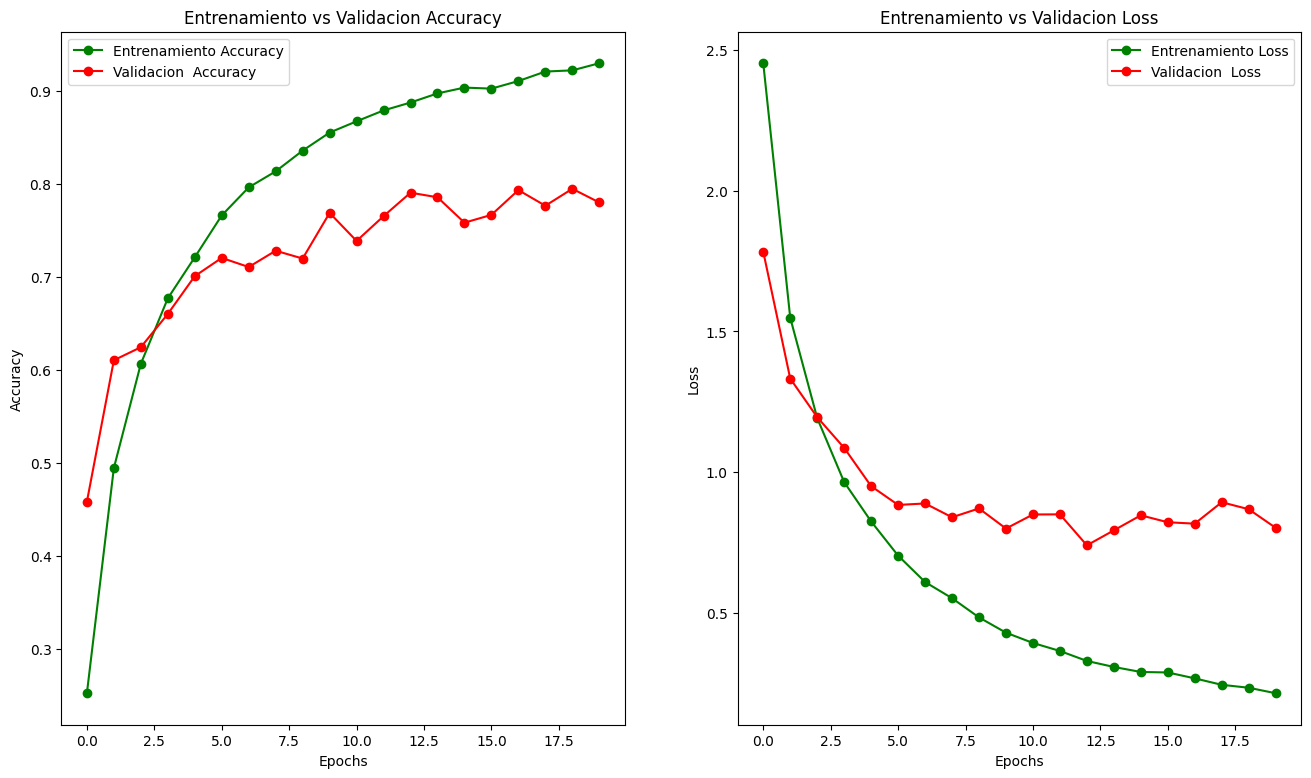

In [ ]:
visualizacion_resultados(history_optimizer)

In [ ]:
model_convolutional = tf.keras.models.Sequential([
                                        tf.keras.layers.Conv2D(75, (3,3),activation="relu", input_shape= (28,28,1)),
                                        tf.keras.layers.MaxPooling2D(2,2),
                                        tf.keras.layers.Flatten(input_shape= (28,28,1)),
                                        tf.keras.layers.Dense(256,kernel_regularizer= regularizers.l2(1e-5), activation="relu"),
                                        tf.keras.layers.Dropout(0.2),
                                        tf.keras.layers.Dense(128, kernel_regularizer= regularizers.l2(1e-5), activation="relu"),
                                        tf.keras.layers.Dropout(0.2),
                                        tf.keras.layers.Dense(len(clases), activation="softmax")
])

model_convolutional.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

history_convolutional = model_convolutional.fit(
    train_generator,
    epochs = 20,
    validation_data = validation_generator
)

Epoch 1/20
 82/215 ━━━━━━━━━━━━━━━━━━━━ 15s 114ms/step - accuracy: 0.1121 - loss: 3.0565

KeyboardInterrupt: 

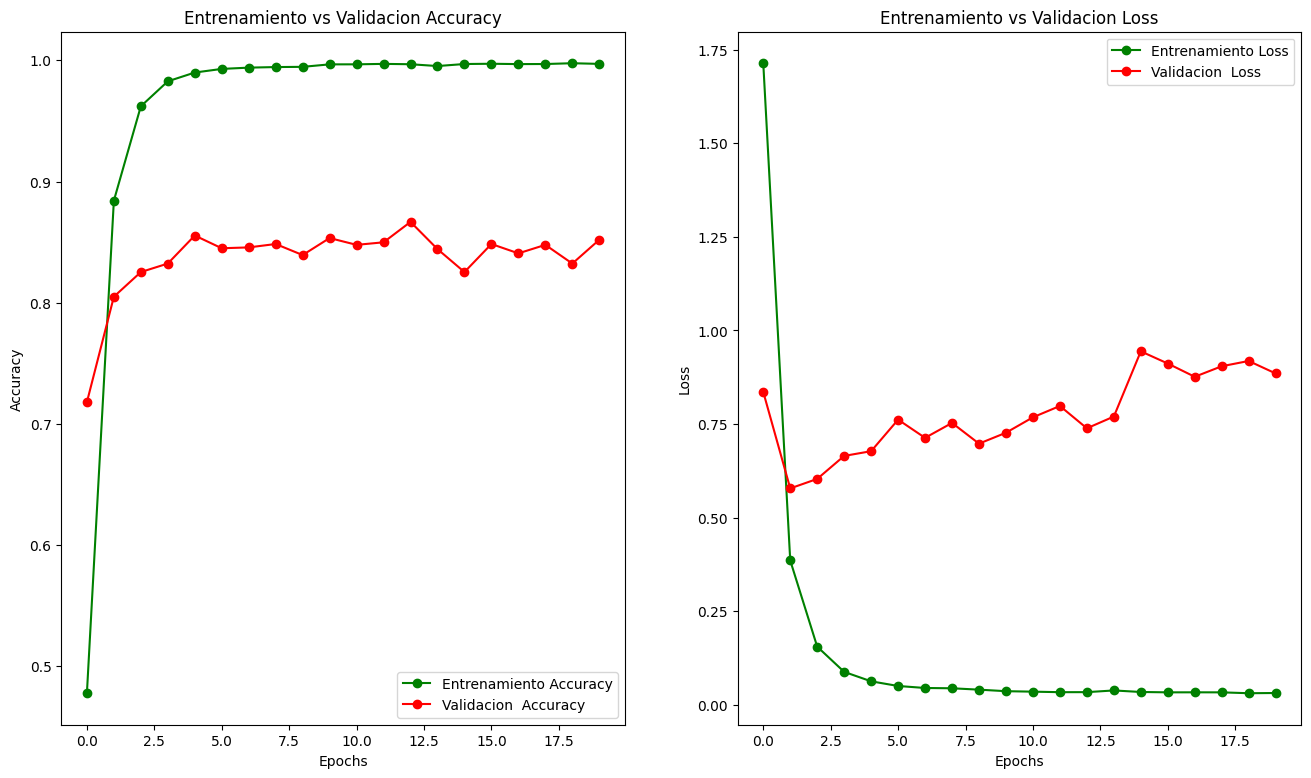

In [ ]:
visualizacion_resultados(history_convolutional)

In [18]:
#METRICAS callbacks
model_callback = tf.keras.models.Sequential([
                                        tf.keras.layers.Conv2D(75, (3,3),activation="relu", input_shape= (28,28,1)),
                                        tf.keras.layers.MaxPooling2D(2,2),
                                        tf.keras.layers.Flatten(input_shape= (28,28,1)),
                                        tf.keras.layers.Dense(256,kernel_regularizer= regularizers.l2(1e-5), activation="relu"),
                                        tf.keras.layers.Dropout(0.2),
                                        tf.keras.layers.Dense(128, kernel_regularizer= regularizers.l2(1e-5), activation="relu"),
                                        tf.keras.layers.Dropout(0.2),
                                        tf.keras.layers.Dense(len(clases), activation="softmax")
])

model_callback.summary()

model_callback.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 75)     │           750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 75)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 12675)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     3,245,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,281,798 (12.52 MB)

 Trainable params: 3,281,798 (12.52 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
from tensorflow.keras.callbacks import Callback

In [13]:
class TrainingCallback(Callback):
  def on_epoch_end(self, epoch, logs={}):
    if logs.get("accuracy") > 0.95:
      print("Lo logramos nuestro modelo llego al 95% , detenemos el entremiento")
      self.model.stop_training = True


In [ ]:
callback = TrainingCallback()

history_callback = model_callback.fit(
    train_generator,
    epochs = 20,
    callbacks=[callback],
    validation_data = validation_generator
)

Epoch 1/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 47s 207ms/step - accuracy: 0.4908 - loss: 1.6925 - val_accuracy: 0.7670 - val_loss: 0.7554
Epoch 2/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 43s 198ms/step - accuracy: 0.8905 - loss: 0.3713 - val_accuracy: 0.8358 - val_loss: 0.5414
Epoch 3/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.9557 - loss: 0.1785Lo logramos nuestro modelo llego al 95% , detenemos el entremiento
215/215 ━━━━━━━━━━━━━━━━━━━━ 42s 197ms/step - accuracy: 0.9640 - loss: 0.1500 - val_accuracy: 0.8470 - val_loss: 0.5136


In [20]:
def get_model():
  model = tf.keras.models.Sequential([
                                        tf.keras.layers.Conv2D(75, (3,3),activation="relu", input_shape= (28,28,1)),
                                        tf.keras.layers.MaxPooling2D(2,2),
                                        tf.keras.layers.Flatten(input_shape= (28,28,1)),
                                        tf.keras.layers.Dense(256,kernel_regularizer= regularizers.l2(1e-5), activation="relu"),
                                        tf.keras.layers.Dropout(0.2),
                                        tf.keras.layers.Dense(128, kernel_regularizer= regularizers.l2(1e-5), activation="relu"),
                                        tf.keras.layers.Dropout(0.2),
                                        tf.keras.layers.Dense(len(clases), activation="softmax")
])
  return model

model_early = get_model()
model_early.summary()

model_early.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 75)     │           750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 75)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 12675)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     3,245,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,281,798 (12.52 MB)

 Trainable params: 3,281,798 (12.52 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callback_early = tf.keras.callbacks.EarlyStopping(
    monitor="loss",
    patience=3,
    mode = "auto"
)

In [ ]:
history_early = model_early.fit(
    train_generator,
    epochs = 20,
    callbacks=[callback_early],
    validation_data = validation_generator
)

Epoch 1/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 46s 208ms/step - accuracy: 0.5034 - loss: 1.6432 - val_accuracy: 0.7481 - val_loss: 0.7962
Epoch 2/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 43s 202ms/step - accuracy: 0.8923 - loss: 0.3626 - val_accuracy: 0.8126 - val_loss: 0.6475
Epoch 3/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 42s 195ms/step - accuracy: 0.9677 - loss: 0.1437 - val_accuracy: 0.8372 - val_loss: 0.6146
Epoch 4/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 42s 194ms/step - accuracy: 0.9857 - loss: 0.0829 - val_accuracy: 0.8400 - val_loss: 0.6409
Epoch 5/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 42s 194ms/step - accuracy: 0.9907 - loss: 0.0622 - val_accuracy: 0.8407 - val_loss: 0.6727
Epoch 6/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 43s 199ms/step - accuracy: 0.9940 - loss: 0.0490 - val_accuracy: 0.8632 - val_loss: 0.6802
Epoch 7/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 42s 193ms/step - accuracy: 0.9952 - loss: 0.0424 - val_accuracy: 0.8358 - val_loss: 0.8296
Epoch 8/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 41s 192ms/step - accuracy: 0.9958 - loss: 0

In [21]:
!pip install -q -U keras-tuner
import kerastuner as kt
from tensorflow import keras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.6 MB/s eta 0:00:00


/tmp/ipykernel_4533/2469124855.py:2: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  import kerastuner as kt


In [22]:
def constructo_modelos(hp):
  model = tf.keras.models.Sequential()
  model.add(tf.keras.layers.Conv2D(75,(3,3), activation="relu", input_shape= (28,28,1)))
  model.add(tf.keras.layers.MaxPooling2D((2,2)))
  model.add(tf.keras.layers.Flatten())

  hp_units = hp.Int("units", min_value=32, max_value=512, step=32)
  model.add(tf.keras.layers.Dense(units=hp_units, activation="relu", kernel_regularizer= regularizers.l2(1e-5)))
  model.add(tf.keras.layers.Dropout(0.2))
  model.add(tf.keras.layers.Dense(128, activation="relu", kernel_regularizer= regularizers.l2(1e-5)))
  model.add(tf.keras.layers.Dropout(0.2))
  model.add(tf.keras.layers.Dense(len(clases), activation="softmax"))

  hp_learning_rate = hp.Choice("learning_rate", values=[1e-2, 1e-3, 1e-4])
  model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate), loss ="categorical_crossentropy", metrics=["accuracy"])

  return model


In [23]:
tuner = kt.Hyperband(
    constructo_modelos,
    objective="val_accuracy",
    max_epochs= 20,
    factor=3,
    directory="models/",
    project_name="projec-personal"
)

In [ ]:
tuner.search(train_generator, epochs = 20, validation_data = validation_generator)
best_hps = tuner.get_best_hyperparameters(num_trials = 1)[0]

Epoch 1/3
215/215 ━━━━━━━━━━━━━━━━━━━━ 26s 115ms/step - accuracy: 0.4810 - loss: 1.7202 - val_accuracy: 0.7277 - val_loss: 0.8179
Epoch 2/3


KeyboardInterrupt: 

In [ ]:
print (best_hps.get("units"))

NameError: name 'best_hps' is not defined

In [ ]:
print (best_hps.get("learning_rate"))

0.001


In [ ]:
hypermodel = tuner.hypermodel.build(best_hps)

history_hypermodel = hypermodel.fit(
    train_generator,
    epochs = 20,
    callbacks=[callback_early],
    validation_data = validation_generator
)

NameError: name 'best_hps' is not defined

In [ ]:
config_dict = hypermodel.get_config()

NameError: name 'hypermodel' is not defined

In [ ]:
print(config_dict)

{'name': 'sequential_1', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'layers': [{'module': 'keras.layers', 'class_name': 'InputLayer', 'config': {'batch_shape': (None, 28, 28, 1), 'dtype': 'float32', 'sparse': False, 'ragged': False, 'name': 'input_layer_1', 'optional': False}, 'registered_name': None}, {'module': 'keras.layers', 'class_name': 'Conv2D', 'config': {'name': 'conv2d_1', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'filters': 75, 'kernel_size': (3, 3), 'strides': (1, 1), 'padding': 'valid', 'data_format': 'channels_last', 'dilation_rate': (1, 1), 'groups': 1, 'activation': 'relu', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name

In [ ]:
model_same_config = tf.keras.Sequential.from_config(config_dict)

In [ ]:
model_same_config.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 75)     │           750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 75)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12675)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 320)            │     4,056,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 320)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,101,254 (15.65 MB)

 Trainable params: 4,101,254 (15.65 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
from tensorflow.keras.callbacks import ModelCheckpoint


In [24]:
model_weight = get_model()
model_weight.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 26, 26, 75)     │           750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 13, 13, 75)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 12675)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │     3,245,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,281,798 (12.52 MB)

 Trainable params: 3,281,798 (12.52 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_weight.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [ ]:
checkpoint_path = "model_checkpoint/mi_modelo.weights.h5"
checkpoint_wieghs = ModelCheckpoint(
    filepath=checkpoint_path,
    save_freq="epoch",
    save_weights_only=True,
    verbose=1
)

In [ ]:
history_weight = model_weight.fit(
    train_generator,
    epochs = 20,
    callbacks=[checkpoint_wieghs],
    validation_data = validation_generator
)

Epoch 1/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.2415 - loss: 2.5484
Epoch 1: saving model to model_checkpoint/mi_modelo.weights.h5

Epoch 1: finished saving model to model_checkpoint/mi_modelo.weights.h5
215/215 ━━━━━━━━━━━━━━━━━━━━ 26s 116ms/step - accuracy: 0.4508 - loss: 1.7955 - val_accuracy: 0.7298 - val_loss: 0.8553
Epoch 2/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.8258 - loss: 0.5511
Epoch 2: saving model to model_checkpoint/mi_modelo.weights.h5

Epoch 2: finished saving model to model_checkpoint/mi_modelo.weights.h5
215/215 ━━━━━━━━━━━━━━━━━━━━ 25s 115ms/step - accuracy: 0.8668 - loss: 0.4349 - val_accuracy: 0.8021 - val_loss: 0.5982
Epoch 3/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.9452 - loss: 0.2126
Epoch 3: saving model to model_checkpoint/mi_modelo.weights.h5

Epoch 3: finished saving model to model_checkpoint/mi_modelo.weights.h5
215/215 ━━━━━━━━━━━━━━━━━━━━ 26s 120ms/step - accuracy: 0.9575 - loss: 0.1756 - val_accu

In [26]:
import os
checkpoint_path = "model_manul/my_model.weights.h5"
os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)
model_weight.save_weights(checkpoint_path)

In [ ]:
model_weight2 = get_model()
model_weight2.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [ ]:
model_weight2.load_weights(checkpoint_path)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
model_weight2.evaluate(test_generator)

57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.8575 - loss: 0.7760


[0.7759512662887573, 0.8575013875961304]

In [ ]:
model_weight.evaluate(test_generator)

57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.8575 - loss: 0.7760


[0.7759510278701782, 0.8575013875961304]

In [ ]:
checkpoint_path = "model_checkpoint_complete/mi_modelo.weights.h5"
checkpoint_wieghs = ModelCheckpoint(
    filepath=checkpoint_path,
    save_freq="epoch",
    save_weights_only=False,
    monitor = "val_accuracy",
    save_best_only = True,
    verbose=1
)

In [ ]:
model_complete = get_model()
model_complete.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

history_complete = model_complete.fit(
    train_generator,
    epochs = 20,
    callbacks=[checkpoint_wieghs],
    validation_data = validation_generator
)

Epoch 1/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.2548 - loss: 2.5308
Epoch 1: val_accuracy improved from None to 0.73754, saving model to model_checkpoint_complete/mi_modelo.weights.h5



Epoch 1: finished saving model to model_checkpoint_complete/mi_modelo.weights.h5
215/215 ━━━━━━━━━━━━━━━━━━━━ 26s 117ms/step - accuracy: 0.4702 - loss: 1.7592 - val_accuracy: 0.7375 - val_loss: 0.8060
Epoch 2/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.8402 - loss: 0.5166
Epoch 2: val_accuracy improved from 0.73754 to 0.81053, saving model to model_checkpoint_complete/mi_modelo.weights.h5



Epoch 2: finished saving model to model_checkpoint_complete/mi_modelo.weights.h5
215/215 ━━━━━━━━━━━━━━━━━━━━ 24s 113ms/step - accuracy: 0.8797 - loss: 0.4003 - val_accuracy: 0.8105 - val_loss: 0.6059
Epoch 3/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.9543 - loss: 0.1830
Epoch 3: val_accuracy improved from 0.81053 to 0.84140, saving model to model_checkpoint_complete/mi_modelo.weights.h5



Epoch 3: finished saving model to model_checkpoint_complete/mi_modelo.weights.h5
215/215 ━━━━━━━━━━━━━━━━━━━━ 24s 112ms/step - accuracy: 0.9639 - loss: 0.1550 - val_accuracy: 0.8414 - val_loss: 0.6525
Epoch 4/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.9811 - loss: 0.0984
Epoch 4: val_accuracy did not improve from 0.84140
215/215 ━━━━━━━━━━━━━━━━━━━━ 24s 112ms/step - accuracy: 0.9844 - loss: 0.0873 - val_accuracy: 0.8372 - val_loss: 0.6234
Epoch 5/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.9892 - loss: 0.0671
Epoch 5: val_accuracy improved from 0.84140 to 0.84281, saving model to model_checkpoint_complete/mi_modelo.weights.h5



Epoch 5: finished saving model to model_checkpoint_complete/mi_modelo.weights.h5
215/215 ━━━━━━━━━━━━━━━━━━━━ 24s 111ms/step - accuracy: 0.9896 - loss: 0.0657 - val_accuracy: 0.8428 - val_loss: 0.7034
Epoch 6/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.9920 - loss: 0.0571
Epoch 6: val_accuracy did not improve from 0.84281
215/215 ━━━━━━━━━━━━━━━━━━━━ 24s 110ms/step - accuracy: 0.9927 - loss: 0.0540 - val_accuracy: 0.8323 - val_loss: 0.7137
Epoch 7/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.9945 - loss: 0.0481
Epoch 7: val_accuracy did not improve from 0.84281
215/215 ━━━━━━━━━━━━━━━━━━━━ 24s 111ms/step - accuracy: 0.9945 - loss: 0.0469 - val_accuracy: 0.8400 - val_loss: 0.7426
Epoch 8/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.9949 - loss: 0.0460
Epoch 8: val_accuracy did not improve from 0.84281
215/215 ━━━━━━━━━━━━━━━━━━━━ 24s 111ms/step - accuracy: 0.9953 - loss: 0.0433 - val_accuracy: 0.8407 - val_loss: 0.7329
Epoch 9/20
215/215 ━━


Epoch 10: finished saving model to model_checkpoint_complete/mi_modelo.weights.h5
215/215 ━━━━━━━━━━━━━━━━━━━━ 24s 111ms/step - accuracy: 0.9963 - loss: 0.0383 - val_accuracy: 0.8477 - val_loss: 0.7018
Epoch 11/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.9976 - loss: 0.0344
Epoch 11: val_accuracy improved from 0.84772 to 0.84912, saving model to model_checkpoint_complete/mi_modelo.weights.h5



Epoch 11: finished saving model to model_checkpoint_complete/mi_modelo.weights.h5
215/215 ━━━━━━━━━━━━━━━━━━━━ 24s 111ms/step - accuracy: 0.9970 - loss: 0.0354 - val_accuracy: 0.8491 - val_loss: 0.7289
Epoch 12/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.9976 - loss: 0.0349
Epoch 12: val_accuracy improved from 0.84912 to 0.86175, saving model to model_checkpoint_complete/mi_modelo.weights.h5



Epoch 12: finished saving model to model_checkpoint_complete/mi_modelo.weights.h5
215/215 ━━━━━━━━━━━━━━━━━━━━ 24s 110ms/step - accuracy: 0.9974 - loss: 0.0356 - val_accuracy: 0.8618 - val_loss: 0.7106
Epoch 13/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.9963 - loss: 0.0378
Epoch 13: val_accuracy did not improve from 0.86175
215/215 ━━━━━━━━━━━━━━━━━━━━ 23s 109ms/step - accuracy: 0.9961 - loss: 0.0382 - val_accuracy: 0.8611 - val_loss: 0.7376
Epoch 14/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.9976 - loss: 0.0333
Epoch 14: val_accuracy did not improve from 0.86175
215/215 ━━━━━━━━━━━━━━━━━━━━ 23s 109ms/step - accuracy: 0.9970 - loss: 0.0341 - val_accuracy: 0.8435 - val_loss: 0.7548
Epoch 15/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9968 - loss: 0.0342
Epoch 15: val_accuracy did not improve from 0.86175
215/215 ━━━━━━━━━━━━━━━━━━━━ 23s 108ms/step - accuracy: 0.9961 - loss: 0.0362 - val_accuracy: 0.8344 - val_loss: 0.8320
Epoch 16/20
21

In [ ]:
model_complete.save("saved_model_complete/mymodel.h5")

In [ ]:
model_complete3 = tf.keras.models.load_model("saved_model_complete/mymodel.h5")

In [27]:
model_complete3.evaluate(test_generator)

NameError: name 'model_complete3' is not defined

In [ ]:
model_complete.evaluate(test_generator)

57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.8646 - loss: 0.7832


[0.7832459211349487, 0.8646124005317688]

In [32]:
import tensorflow as tf
model = tf.keras.models.load_model('/content/mymodel.h5')

print(model)

<Sequential name=sequential_3, built=True>


In [33]:
model.evaluate(test_generator)

57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - accuracy: 0.8646 - loss: 0.7832


[0.783245861530304, 0.8646124005317688]

In [34]:
model_pesos = tf.keras.models.load_model('/content/mi_modelo.weights.h5')

In [35]:
print(model_pesos)

<Sequential name=sequential_3, built=True>


In [36]:
model_pesos.evaluate(test_generator)

57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.8682 - loss: 0.6504


[0.6504062414169312, 0.8682376146316528]